# ***Forecasting non-stationary time series(ARIMAmodel)***

**Now we’ll add another component to the ARMA(p,q) model so we can
forecast non-stationary time series. This component is the integration order,
which is denoted by the variable d. This leads us to the autoregressive
integrated moving average (ARIMA) model, or ARIMA(p,d,q). Using this
model, we can take into account non-stationary time series and avoid the
steps of modeling on differenced data and having to inverse transform the
forecasts**

# **Defining the autoregressive integratedvmoving average model**

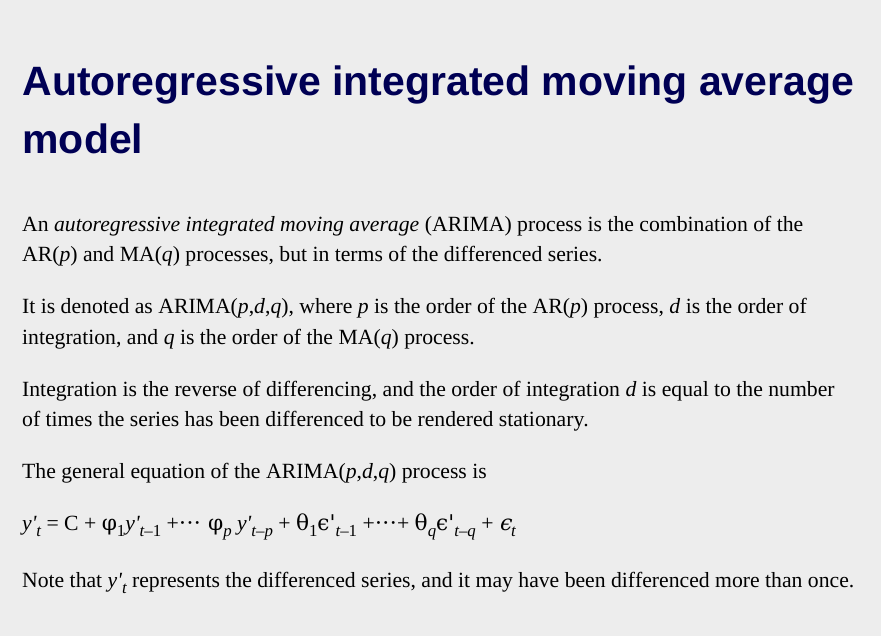

A time series that can be rendered stationary by applying differencing is said
to be an integrated series. In the presence of a non-stationary integrated time
series, we can use the ARIMA(p,d,q) model to produce forecasts.
Thus, in simple terms, the ARIMA model is simply an ARMA model that
can be applied on non-stationary time series. Whereas the ARMA(p,q)
model requires the series to be stationary before fitting an ARMA(p,q)
model, the ARIMA(p,d,q) model can be used on non-stationary series. We
must simply find the order of integration d, which corresponds to the
minimum number of times a series must be differenced to become stationary.
Therefore, we must add the step of finding the order of integration to our
general modeling procedure before we apply it to forecast the quarterly EPS
of Johnson & Johnson.

### **Forecasting a non-stationary times series**

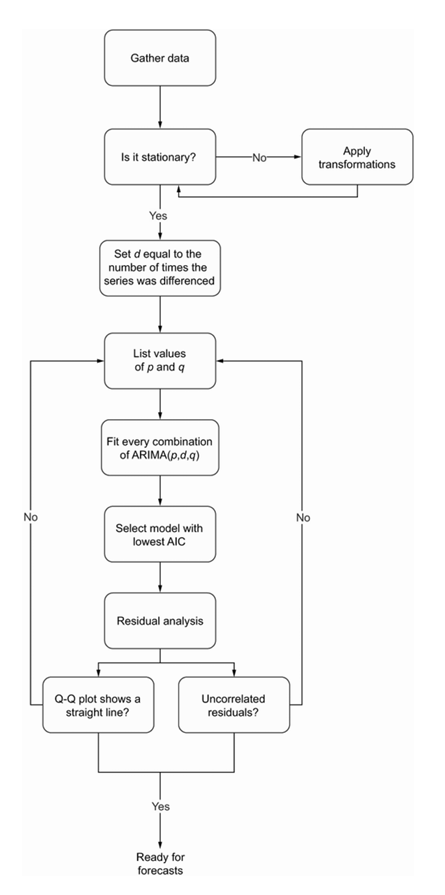

**General modeling procedure for using the ARIMA(p,d,q)
model. Notice the addition of a step where we specify the parameter d
for the ARIMA(p,d,q) model. Here, d is simply the minimum number of
times a series must be differenced to become stationary.**

In [166]:
# importing libraries and prerequisite
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### **VISUALIZING OUR DATA**

In [167]:
df=pd.read_csv('jj_eps_formatted.csv')
df.head()

,Unnamed: 0,date,data
0,0,1960-01-01,0.71
1,1,1960-04-01,0.63
2,2,1960-07-02,0.85
3,3,1960-10-01,0.44
4,4,1961-01-01,0.61


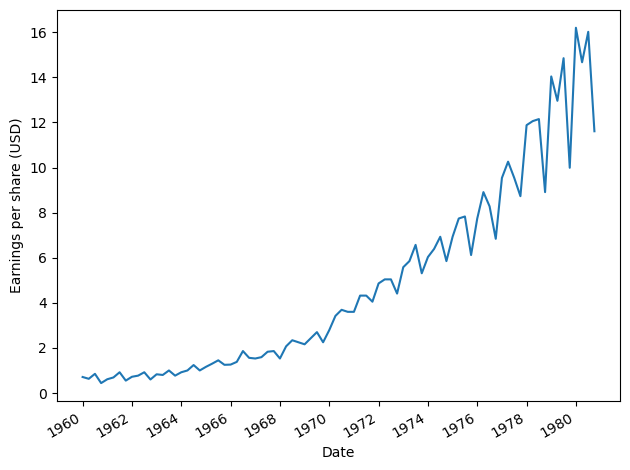

In [168]:
fig ,ax=plt.subplots()
ax.plot(df.date,df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
plt.xticks(np.arange(0,81,8),[1960,1962,1964,1966,1968,1970,1972,1974,1976,1978,1980])
fig.autofmt_xdate()
plt.tight_layout()

**Quarterly earnings per share (EPS) of Johnson & Johnson
between 1960 and 1980**

### **Cheaking Stationarity**

In [169]:
sts.adfuller(df['data'])

(np.float64(2.74201695704067),
 1.0,
 11,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(82.63762654537308))

**As we can see the p-value is 1 which is greater than 0.05 nad test-statistic is greater than table value so it implies that the data is not stationary**

#### **We need to determine how many times the series must be differenced to become stationary. This will then set the order of integration d. We can apply a first-order differencing and test for stationarity.**

### **APPLYING DIFFERENCING AND CHECKING STATIONARITY**

In [170]:
eps_diff=np.diff(df['data'],n=1)
sts.adfuller(eps_diff)

(np.float64(-0.4074097640820855),
 np.float64(0.9088542416161073),
 10,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(89.21319702542243))

**We can see that still the data is not stationary, so we again apply differencing and check stationarity**

In [171]:
eps_diff2=np.diff(eps_diff,n=1)
sts.adfuller(eps_diff2)

(np.float64(-3.5851630823990592),
 np.float64(0.006051095719849057),
 9,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(87.33902577131795))

**Here we can see the p-value =0.006 which is smaller than 0.05 and test-statistic < table values so our dta is stationary**

### **Splitting the data into train and test data**

Before we move on to fitting different combinations of ARIMA(p,d,q)
models, we must separate our data into train and test sets. We will hold out
the last year of data for testing. This means that we will fit the model with
data from 1960 to 1979 and predict the quarterly EPS in 1980 to evaluate the
quality of our model against the observed values in 1980. In figure 7.6 the
testing period is the shaded area.

In [172]:
train=df[:-4]
test=df[-4:]
print(len(train))
print(len(test))

80
4


### **Visualizing the train and test area**

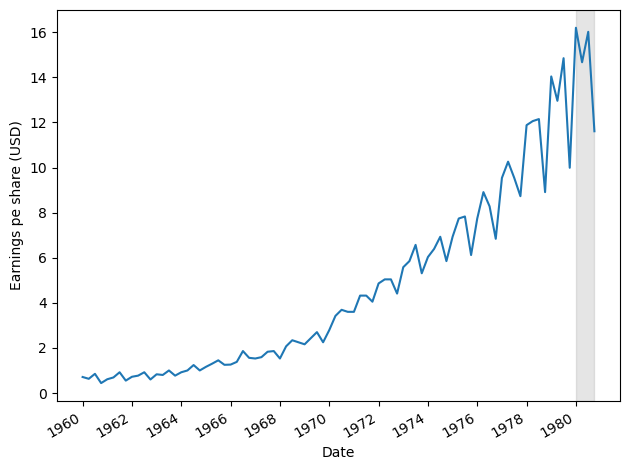

In [173]:
fig ,ax=plt.subplots()
ax.plot(df.date,df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings pe share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0,81,8),[1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

**The train and test sets. The training period spans the years
1960 to 1979 inclusively, while the test set is the quarterly EPS reported
in 1980. This test set corresponds to the last four data points of the
dataset.**

## **Function to fit all unique ARIMA(p,d,q) models**

In [174]:
ps=range(0,4,1)
qs=range(0,4,1)
order_list=list(product(ps,qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [175]:
for (p,q) in order_list:
    model=SARIMAX(train['data'],order=(p,2,q)).fit()
    print(p,q,model.aic)

0 0 320.32442861554085
0 1 252.60099732193476
0 2 209.27456517362813
0 3 194.6547175106251
1 0 280.38937861855186
1 1 236.1172328577905
1 2 228.9357920791511
1 3 228.26772919952435
2 0 280.2998997531592
2 1 234.50110634907057
2 2 229.97465555821037
2 3 220.66685183143457
3 0 154.43064479623504
3 1 115.62500250204494
3 2 115.67202980531636
3 3 115.26788591230172


In [176]:
# method 2
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [177]:
result_df = optimize_ARIMA(train['data'], order_list, 2)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(3, 3)",115.267886
1,"(3, 1)",115.625003
2,"(3, 2)",115.672030
3,"(3, 0)",154.430645
4,"(0, 3)",194.654718
5,"(0, 2)",209.274565
6,"(2, 3)",220.666852
7,"(1, 3)",228.267729
8,"(1, 2)",228.935792
9,"(2, 2)",229.974656


**The returned DataFrame shows that a value of 3 for both p and q results in
the lowest AIC. Therefore, an ARIMA(3,2,3) model seems to be the most
suitable for this situation. Now let’s assess the validity of the model by
studying its residuals**

In [188]:
model = SARIMAX(train['data'], order=(3,2,3), simple_differencing=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   80
Model:               SARIMAX(3, 2, 3)   Log Likelihood                 -50.634
Date:                Sun, 17 May 2026   AIC                            115.268
Time:                        15:44:57   BIC                            131.765
Sample:                             0   HQIC                           121.872
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9991      0.037    -27.155      0.000      -1.071      -0.927
ar.L2         -0.9879      0.039    -25.182      0.000      -1.065      -0.911
ar.L3         -0.9761      0.026    -38.037      0.0

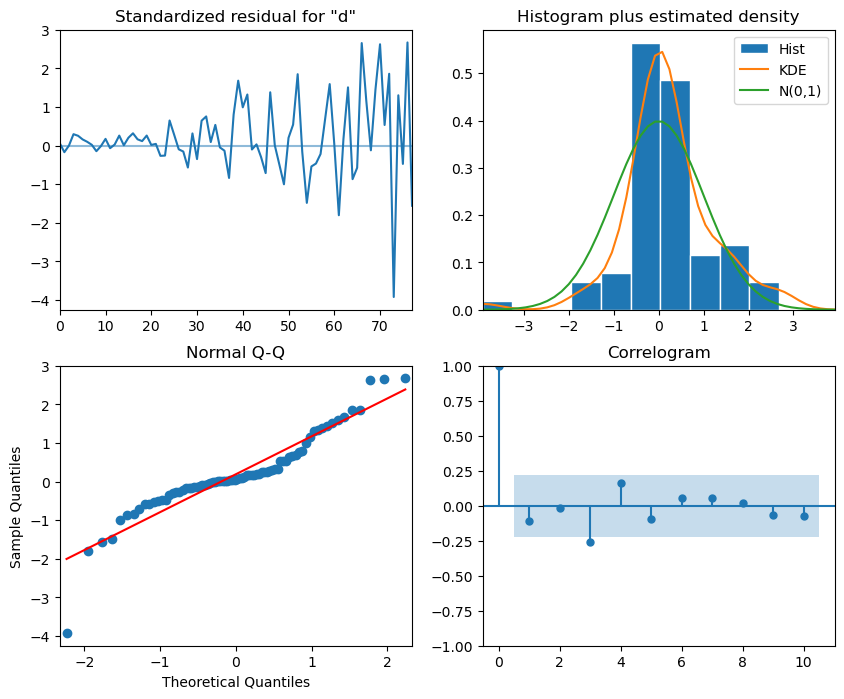

In [ ]:
model_fit.plot_diagnostics(figsize=(10,8));

***Diagnostics of the ARIMA(3,2,3) residuals. The Q-Q plot at
the bottom left displays a fairly straight line with some deviation at the
extremities.***

In figure , the top-left plot shows the residuals over time. While there is
no trend in the residuals, the variance does not seem to be constant, which is
a discrepancy in comparison to white noise. At the top right is the
distribution of the residuals. We can see it is fairly close to a normal
distribution. The Q-Q plot leads us to the same conclusion, as it displays a
line that is fairly straight, meaning that the residuals’ distribution is close to
a normal distribution. Finally, by looking at the correlogram at the bottom
right, we can see that a coefficient seems to be significant at lag 3. However,
since it is not preceded by any significant autocorrelation coefficients, we
can assume that this is due to chance. Therefore, we can say that the
correlogram shows no significant coefficients after lag 0, just like white
noise.
Thus, from a qualitative standpoint, it seems that our residuals are close to
white noise, which is a good sign, as it means that the model’s errors are
random.

**The last step is to evaluate the residuals from a quantitative standpoint. We’ll
thus apply the Ljung-Box test to determine whether the residuals are
correlated. We’ll apply the test on the first 10 lags and study the p-values. If
all p-values are greater than 0.05, we cannot reject the null hypothesis and
we’ll conclude that the residuals are not correlated, just like white noise.**

In [ ]:
residuals = model_fit.resid
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,1.601519,0.205688
2,1.603389,0.448568
3,7.217482,0.065280
4,9.140195,0.057689
5,9.759519,0.082343
6,10.002312,0.124555
7,10.258281,0.174403
8,10.290466,0.245228
9,10.636192,0.301472
10,11.078552,0.351431


Running the Ljung-Box test on the first 10 lags of the model’s residuals
returns a list of p-values that are all larger than 0.05. Therefore, we do not
reject the null hypothesis, and we conclude that the residuals are not
correlated, just like white noise.

## **FITTING THE MODEL**

In [179]:

test = df.iloc[-4:]
test['naive_seasonal'] = df['data'].iloc[76:80].values
test['naive_seasonal']

80    14.04
81    12.96
82    14.85
83     9.99
Name: naive_seasonal, dtype: float64

In [182]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean    
test['ARIMA_pred'] = ARIMA_pred
test['ARIMA_pred']

80    15.859208
81    14.382903
82    16.369467
83    11.679616
Name: ARIMA_pred, dtype: float64

### **visualizing our data**

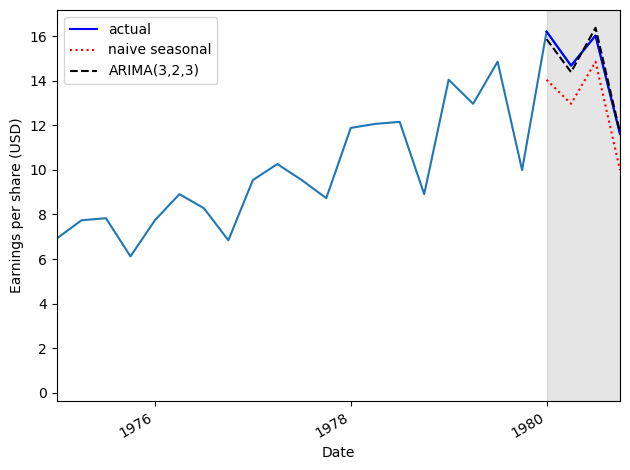

In [183]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.plot(test['data'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(3,2,3)')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax.set_xlim(60, 83)

fig.autofmt_xdate()
plt.tight_layout()

***Forecasts of the quarterly EPS of Johnson & Johnson in
1980. We can see that the predictions coming from the ARIMA(3,2,3)
model, shown as a dashed line, almost perfectly overlap the observed
data in 1980.***

## ***ERRORS***

In [184]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [185]:
mape_naive_seasonal = mape(test['data'], test['naive_seasonal'])
mape_ARIMA = mape(test['data'], test['ARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA)

11.561658552433654 1.7104376210621872


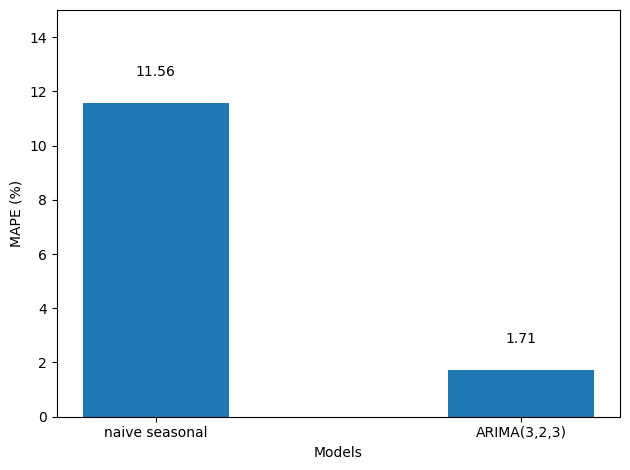

In [186]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(3,2,3)']
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

#### **The MAPE for both forecasting methods. You can see that the ARIMA model has an error metric that is one fifth of the baseline.**